<a href="https://colab.research.google.com/github/vishnuvardhan1699/2520030392_ML/blob/main/Practical/Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
df = pd.read_csv("/content/housing.csv")

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
print("Shape:", df.shape)
print("Columns:")
print(df.columns)

Shape: (20640, 10)
Columns:
Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')


In [ ]:
target_col = "median_house_value"

X = df.drop(columns=[target_col])
y = df[target_col]

print("Target variable:", target_col)
print("X shape:", X.shape)
print("y shape:", y.shape)

Target variable: median_house_value
X shape: (20640, 9)
y shape: (20640,)


In [ ]:
X = pd.get_dummies(X, columns=["ocean_proximity"], dtype=int)

X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,0,0,0,1,0


In [ ]:
X = X.fillna(X.median())

print("Missing values:")
print(X.isnull().sum().sum())

Missing values:
0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (16512, 13)
Testing data: (4128, 13)


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature scaling completed")

Feature scaling completed


In [ ]:
X_train_b = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test_b = np.c_[np.ones((X_test.shape[0], 1)), X_test]

print("X_train_b:", X_train_b.shape)
print("X_test_b:", X_test_b.shape)

X_train_b: (16512, 14)
X_test_b: (4128, 14)


In [ ]:
def gradient_descent(X, y, lr=0.01, n_iters=1000):
    m, n = X.shape
    theta = np.zeros((n, 1))
    losses = []

    y = np.array(y).reshape(-1, 1)

    for i in range(n_iters):
        y_pred = X @ theta
        error = y_pred - y

        loss = (1 / (2 * m)) * np.sum(error ** 2)
        losses.append(loss)

        gradient = (1 / m) * (X.T @ error)

        theta -= lr * gradient

        if i % 100 == 0:
            print(f"Iteration {i} | Loss: {loss:.4f}")

    return theta, losses

In [ ]:
theta, losses = gradient_descent(
    X_train_b,
    y_train,
    lr=0.01,
    n_iters=1000
)

Iteration 0 | Loss: 28148711615.5157
Iteration 100 | Loss: 5786195356.0558
Iteration 200 | Loss: 2979249896.2540
Iteration 300 | Loss: 2577270401.6875
Iteration 400 | Loss: 2500324287.4087
Iteration 500 | Loss: 2472471586.0086
Iteration 600 | Loss: 2454850832.2689
Iteration 700 | Loss: 2441176267.1334
Iteration 800 | Loss: 2429965314.0188
Iteration 900 | Loss: 2420589477.9909


In [ ]:
y_pred = X_test_b @ theta

print("Predictions:")
print(y_pred[:5].ravel())

Predictions:
[ 53920.75903157 109704.57123891 267641.104      273903.93397521
 252166.64267635]


In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Final weights:")
print(theta.ravel())

print(f"Test MSE: {mse:.4f}")
print(f"Test R²: {r2:.4f}")

Final weights:
[207185.7488845  -16853.76182047 -15543.90977127  14626.99375893
   4709.48441899  18824.8273554  -32730.47708912  15650.81331871
  71966.97982587   9545.3706703  -21543.84827115   2708.75764022
   6220.70707251   9846.87107675]
Test MSE: 4974954915.9486
Test R²: 0.6204


In [ ]:
from sklearn.linear_model import LinearRegression

sk_model = LinearRegression()

sk_model.fit(X_train, y_train)

sk_pred = sk_model.predict(X_test)

sk_r2 = r2_score(y_test, sk_pred)

print(f"sklearn LinearRegression R²: {sk_r2:.4f}")

sklearn LinearRegression R²: 0.6254


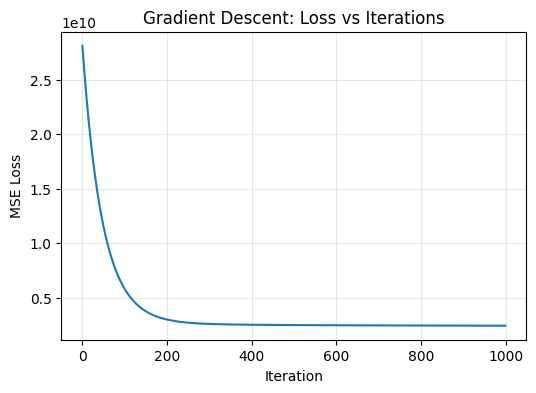

In [ ]:
plt.figure(figsize=(6, 4))

plt.plot(range(len(losses)), losses)

plt.title("Gradient Descent: Loss vs Iterations")
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.grid(alpha=0.3)

plt.show()

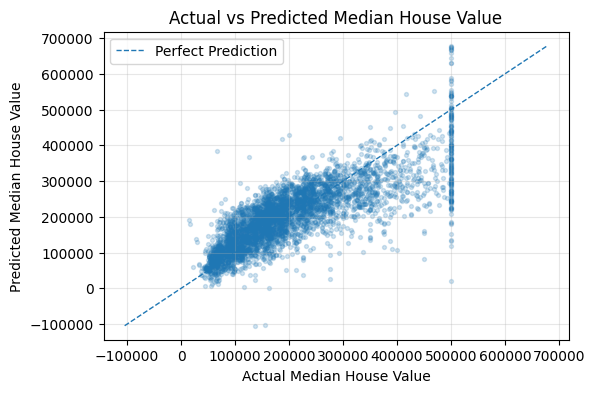

In [ ]:
plt.figure(figsize=(6, 4))

plt.scatter(y_test, y_pred, alpha=0.2, s=8)

lims = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())
]

plt.plot(
    lims,
    lims,
    linestyle="--",
    linewidth=1,
    label="Perfect Prediction"
)

plt.title("Actual vs Predicted Median House Value")
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [ ]:
df = pd.read_csv("/content/housing.csv")

print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

Dataset Shape: (20640, 10)

Columns:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']


In [ ]:
median_value = df["median_house_value"].median()

df["house_value_class"] = (
    df["median_house_value"] > median_value
).astype(int)

y = df["house_value_class"]

print("Median House Value:", median_value)

print("\nTarget Distribution:")
print(y.value_counts())

Median House Value: 179700.0

Target Distribution:
house_value_class
0    10323
1    10317
Name: count, dtype: int64


In [ ]:
features = [
    "longitude",
    "latitude",
    "housing_median_age",
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "median_income",
    "ocean_proximity"
]

X = df[features].copy()

print(X.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income ocean_proximity  
0       322.0       126.0         8.3252        NEAR BAY  
1      2401.0      1138.0         8.3014        NEAR BAY  
2       496.0       177.0         7.2574        NEAR BAY  
3       558.0       219.0         5.6431        NEAR BAY  
4       565.0       259.0         3.8462        NEAR BAY  


In [ ]:
categorical_features = [
    "ocean_proximity"
]

In [ ]:
numerical_features = [
    "longitude",
    "latitude",
    "housing_median_age",
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "median_income"
]

In [ ]:
for col in numerical_features:
    X[col] = X[col].fillna(X[col].median())

for col in categorical_features:
    X[col] = X[col].fillna(X[col].mode()[0])

print("Missing values:")
print(X.isnull().sum())

Missing values:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
ocean_proximity       0
dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (16512, 9)
Testing data: (4128, 9)


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ]
)

In [ ]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

In [ ]:
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [ ]:
y_pred = logistic_model.predict(X_test)

y_probability = logistic_model.predict_proba(X_test)[:, 1]

print("Predictions:")
print(y_pred[:10])

print("\nProbabilities:")
print(y_probability[:10])

Predictions:
[1 1 1 0 0 1 1 0 1 1]

Probabilities:
[0.9004479  0.96273777 0.97636774 0.40236892 0.04282347 0.77546808
 0.84424081 0.15113498 0.87911108 0.96711049]


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:")
print(round(accuracy, 4))

Accuracy:
0.8377


In [ ]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[1718  347]
 [ 323 1740]]


In [ ]:
print("Classification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Below/Equal Median",
            "Above Median"
        ]
    )
)

Classification Report:
                    precision    recall  f1-score   support

Below/Equal Median       0.84      0.83      0.84      2065
      Above Median       0.83      0.84      0.84      2063

          accuracy                           0.84      4128
         macro avg       0.84      0.84      0.84      4128
      weighted avg       0.84      0.84      0.84      4128



In [ ]:
roc_auc = roc_auc_score(y_test, y_probability)

print("ROC-AUC:")
print(round(roc_auc, 4))

ROC-AUC:
0.9211


In [ ]:
print("============================================")
print("LOGISTIC REGRESSION RESULTS")
print("============================================")

print("\nMedian House Value:")
print(median_value)

print("\nAccuracy:")
print(round(accuracy, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nROC-AUC:")
print(round(roc_auc, 4))

LOGISTIC REGRESSION RESULTS

Median House Value:
179700.0

Accuracy:
0.8377

Confusion Matrix:
[[1718  347]
 [ 323 1740]]

ROC-AUC:
0.9211
